In [10]:
import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns


=== Performance Tables (test/MFO) ===

--- Fmax (Higher is better) ---
                                                         Model              Checkpoint      Fmax
0           20251202_010908_D1_2layerGNN_STRINGDB_CONTACT_ATTR  checkpoint_epoch_4_MFO  0.621104
1                   20251118_143647_D1_2layerGNN_STRINGDB_ATTR  checkpoint_epoch_6_MFO  0.616682
2                20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR   checkpoint_latest_MFO  0.616650
3                         20251119_001551_D1_2layerGNN_CONTACT   checkpoint_latest_MFO  0.614989
4                    20251118_150705_D1_2layerGNN_CONTACT_ATTR  checkpoint_epoch_6_MFO  0.613588
5              20251121_055839_D1_2layerGNN_NOSYS_CONTACT_ATTR   checkpoint_latest_MFO  0.612883
6  20251119_233156_D1_2layerGNN_default_CONTACT_ATTR_SWISS_CUR  checkpoint_epoch_1_MFO  0.595695
7                                 20251204_093632_D1_2layerGNN  checkpoint_epoch_5_MFO  0.583405
8               20251118_135639_D1_2layerGNN_default_SW

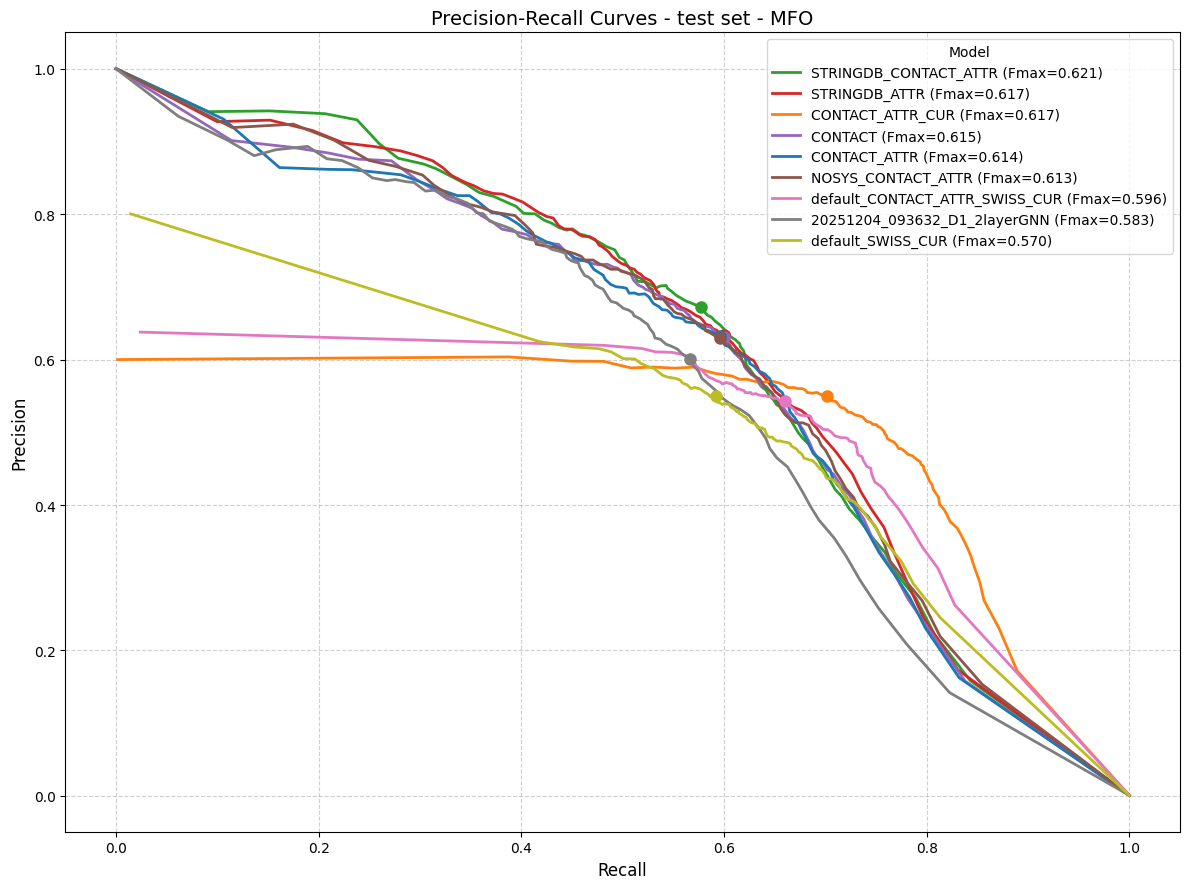

In [ ]:

# Configuration
GLOBAL_EVAL_DIR = "/home/atoffano/PFP_layer/results/D1/global_eval"
SPLIT = "test"
SUBONTOLOGY = "MFO"

def load_data():
    all_data = []
    
    if not os.path.exists(GLOBAL_EVAL_DIR):
        print(f"Error: Directory {GLOBAL_EVAL_DIR} not found.")
        return pd.DataFrame()

    # Traverse: model / checkpoint / split / subontology / beprof-eval / beprof_eval_results.pkl
    # Get all model directories
    try:
        models = [d for d in os.listdir(GLOBAL_EVAL_DIR) if os.path.isdir(os.path.join(GLOBAL_EVAL_DIR, d))]
    except OSError as e:
        print(f"Error accessing {GLOBAL_EVAL_DIR}: {e}")
        return pd.DataFrame()
    
    for model in models:
        model_dir = os.path.join(GLOBAL_EVAL_DIR, model)
        checkpoints = [d for d in os.listdir(model_dir) if os.path.isdir(os.path.join(model_dir, d))]
        
        for ckpt in checkpoints:
            # Construct path to the specific result file
            result_path = os.path.join(
                model_dir, 
                ckpt, 
                SPLIT, 
                SUBONTOLOGY, 
                "beprof-eval", 
                "beprof_eval_results.pkl"
            )
            
            if os.path.exists(result_path):
                try:
                    with open(result_path, 'rb') as f:
                        res = pickle.load(f)
                    
                    all_data.append({
                        'Model': model,
                        'Checkpoint': ckpt,
                        'Fmax': res.get('result_fmax', 0.0),
                        'Smin': res.get('result_smin', float('inf')),
                        'Precisions': res.get('precisions'),
                        'Recalls': res.get('recalls')
                    })
                except Exception as e:
                    print(f"Failed to load {result_path}: {e}")
    
    return pd.DataFrame(all_data)

def main():
    df = load_data()
    
    if df.empty:
        print("No data found. Check your GLOBAL_EVAL_DIR path and ensure evaluations have run.")
        return

    # Select best checkpoint per model based on Fmax
    # Sort by Fmax descending so the first occurrence of a model is its best
    df_best = df.sort_values('Fmax', ascending=False).drop_duplicates(subset='Model', keep='first')
    
    # 1. Tables
    print(f"\n=== Performance Tables ({SPLIT}/{SUBONTOLOGY}) ===")
    
    print("\n--- Fmax (Higher is better) ---")
    fmax_table = df_best[['Model', 'Checkpoint', 'Fmax']].sort_values('Fmax', ascending=False).reset_index(drop=True)
    print(fmax_table.to_string())
    
    print("\n--- Smin (Lower is better) ---")
    smin_table = df_best[['Model', 'Checkpoint', 'Smin']].sort_values('Smin', ascending=True).reset_index(drop=True)
    print(smin_table.to_string())

    # 2. Plotting
    plt.figure(figsize=(12, 9))
    
    # Custom color mapping
    # Custom color mapping with increased saturation
    from matplotlib.colors import to_rgba

    custom_colors = {
        "20251118_150705_D1_2layerGNN_CONTACT_ATTR": to_rgba("tab:blue", alpha=1.0),
        "20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR": to_rgba("tab:orange", alpha=1.0)
    }    
    # Get tab10 colormap
    cmap = plt.get_cmap('tab10')
    # Start index for other models (skip 0=blue, 1=orange to avoid confusion)
    color_idx = 2
    
    # Plot curves for best models
    for _, row in df_best.iterrows():
        recalls = row['Recalls']
        precisions = row['Precisions']
        model_name = row['Model']
        
        if recalls is not None and precisions is not None:
            # Determine color
            if model_name in custom_colors:
                color = custom_colors[model_name]
            else:
                color = cmap(color_idx % 10)
                color_idx += 1

            # Label with Fmax
            label = f"{row['Model']} (Fmax={row['Fmax']:.3f})"
            line, = plt.plot(recalls, precisions, label=label, linewidth=2, color=color)

            # Calculate F-score for each point to find the location of Fmax
            r_arr = np.array(recalls)
            p_arr = np.array(precisions)
            
            # Compute F-scores safely
            with np.errstate(divide='ignore', invalid='ignore'):
                f_scores = 2 * p_arr * r_arr / (p_arr + r_arr)
            
            # Handle NaNs (0/0) by replacing with 0
            f_scores = np.nan_to_num(f_scores)
            
            # Find the index of the maximum F-score
            best_idx = np.argmax(f_scores)
            
            # Plot the dot at Fmax location using the same color as the line
            plt.plot(r_arr[best_idx], p_arr[best_idx], 'o', color=line.get_color(), markersize=8)

    plt.xlabel('Recall', fontsize=12)

    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Precision-Recall Curves - {SPLIT} set - {SUBONTOLOGY}', fontsize=14)
    
    # Legend inside the figure (loc='best' automatically finds a spot with minimal overlap)
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = [label.split('GNN_')[-1] for label in labels]
    plt.legend(handles, new_labels, title='Model', loc='best', fontsize=10)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
if __name__ == "__main__":
    main()

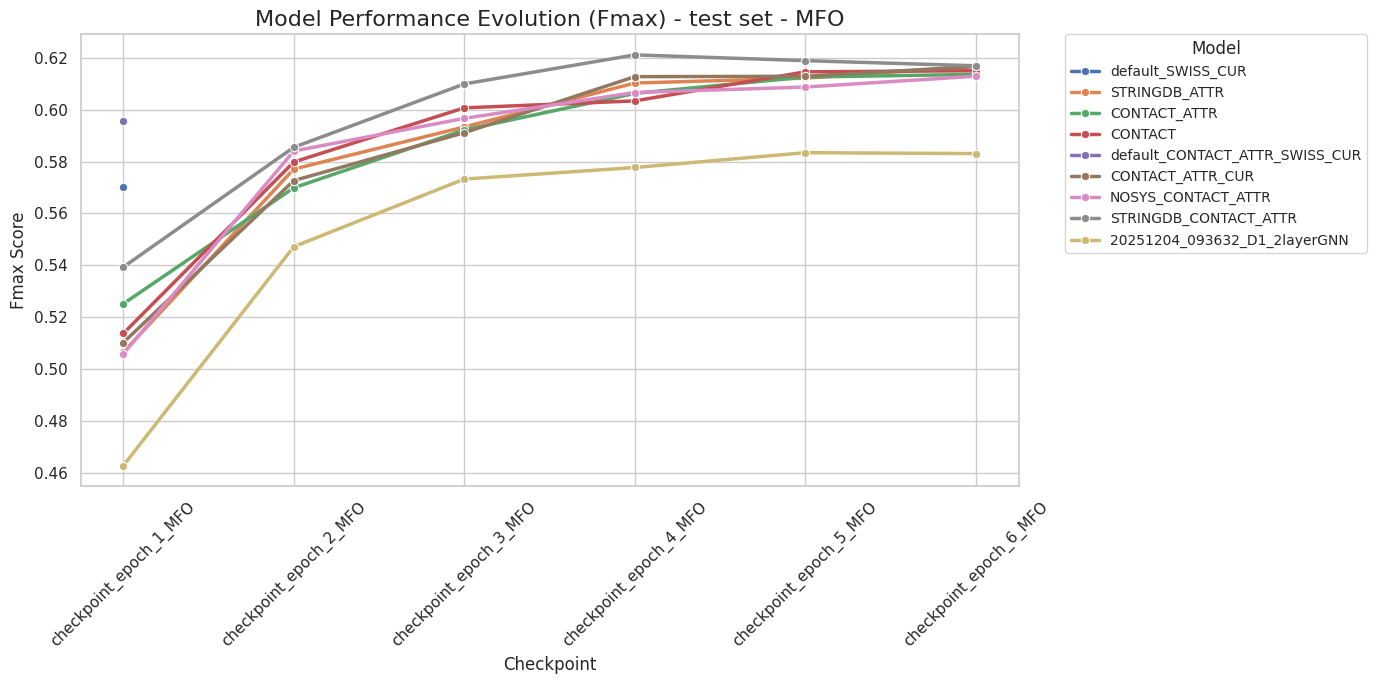

In [3]:
import seaborn as sns
df_filtered = load_data()

# Filter out 'checkpoint_latest' from the dataframe
df_filtered = df_filtered[df_filtered['Checkpoint'] != 'checkpoint_latest_MFO']
df_filtered = df_filtered.sort_values(['Model', 'Checkpoint'])
if not df_filtered.empty:
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # Plot using seaborn lineplot
    sns.lineplot(
        data=df_filtered, 
        x='Checkpoint', 
        y='Fmax', 
        hue='Model', 
        marker='o',
        linewidth=2.5
    )

    plt.title(f'Model Performance Evolution (Fmax) - {SPLIT} set - {SUBONTOLOGY}', fontsize=16)
    plt.xlabel('Checkpoint', fontsize=12)
    plt.ylabel('Fmax Score', fontsize=12)
    plt.xticks(rotation=45)
    
    # Remove 'GNN_' and all that came befor from legend labels for clarity
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = [label.split('GNN_')[-1] for label in labels]
    plt.legend(handles, new_labels, title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot after filtering.")

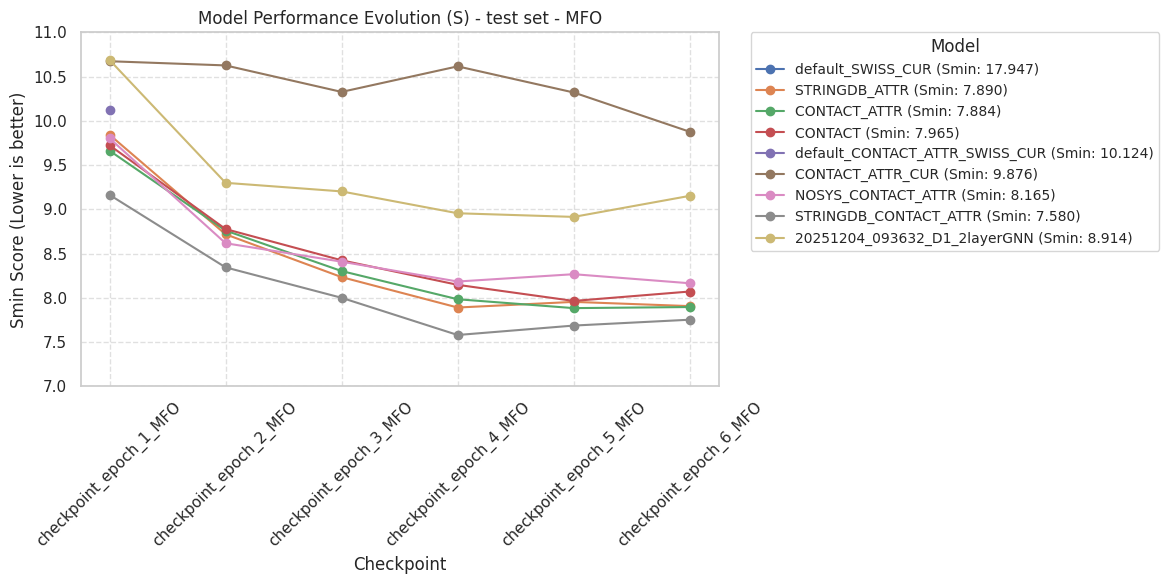

In [4]:
if not df_filtered.empty:
    plt.figure(figsize=(12, 6))

    # Get unique models (already defined as 'models' in previous cell, but safe to reuse from df_filtered)
    models = df_filtered['Model'].unique()

    for model in models:
        model_data = df_filtered[df_filtered['Model'] == model]
        
        # Plot Smin evolution
        # Smin is "lower is better", so we highlight the minimum value
        plt.plot(model_data['Checkpoint'], model_data['Smin'], marker='o', label=f"{model} (Smin: {model_data['Smin'].min():.3f})")

    plt.xlabel('Checkpoint')
    plt.ylabel('Smin Score (Lower is better)')
    plt.title(f'Model Performance Evolution (S) - {SPLIT} set - {SUBONTOLOGY}')
    plt.xticks(rotation=45)
    plt.ylim(7,11)
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = [label.split('GNN_')[-1] for label in labels]
    plt.legend(handles, new_labels, title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot evolution.")


=== CAFA Performance Tables (test/MFO) ===

--- Fmax (Standard) ---
                                                         Model              Checkpoint   Fmax
0           20251202_010908_D1_2layerGNN_STRINGDB_CONTACT_ATTR  checkpoint_epoch_4_MFO  0.678
1                   20251118_143647_D1_2layerGNN_STRINGDB_ATTR   checkpoint_latest_MFO  0.672
2                         20251119_001551_D1_2layerGNN_CONTACT  checkpoint_epoch_5_MFO  0.670
3                    20251118_150705_D1_2layerGNN_CONTACT_ATTR   checkpoint_latest_MFO  0.668
4              20251121_055839_D1_2layerGNN_NOSYS_CONTACT_ATTR   checkpoint_latest_MFO  0.666
5                20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR   checkpoint_latest_MFO  0.657
6                                 20251204_093632_D1_2layerGNN  checkpoint_epoch_5_MFO  0.640
7  20251119_233156_D1_2layerGNN_default_CONTACT_ATTR_SWISS_CUR   checkpoint_latest_MFO  0.639
8               20251118_135639_D1_2layerGNN_default_SWISS_CUR  checkpoint_epoch_1_MF

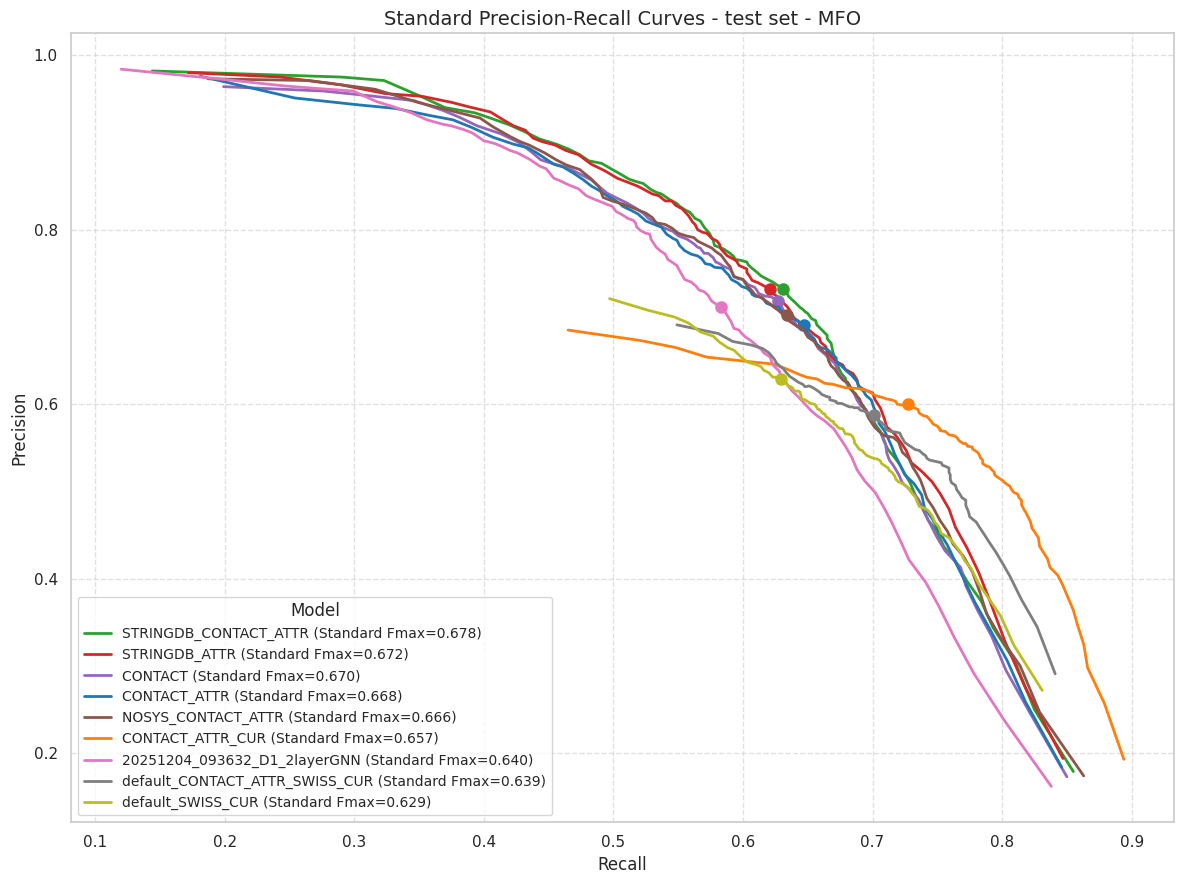


--- Fmax (Weighted) ---
                                                         Model              Checkpoint  Fmax_w
0                                 20251204_093632_D1_2layerGNN  checkpoint_epoch_6_MFO   0.544
1               20251118_135639_D1_2layerGNN_default_SWISS_CUR   checkpoint_latest_MFO     NaN
2                   20251118_143647_D1_2layerGNN_STRINGDB_ATTR  checkpoint_epoch_6_MFO     NaN
3           20251202_010908_D1_2layerGNN_STRINGDB_CONTACT_ATTR  checkpoint_epoch_6_MFO     NaN
4              20251121_055839_D1_2layerGNN_NOSYS_CONTACT_ATTR  checkpoint_epoch_6_MFO     NaN
5                20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR  checkpoint_epoch_6_MFO     NaN
6                         20251119_001551_D1_2layerGNN_CONTACT  checkpoint_epoch_6_MFO     NaN
7  20251119_233156_D1_2layerGNN_default_CONTACT_ATTR_SWISS_CUR   checkpoint_latest_MFO     NaN
8                    20251118_150705_D1_2layerGNN_CONTACT_ATTR  checkpoint_epoch_6_MFO     NaN


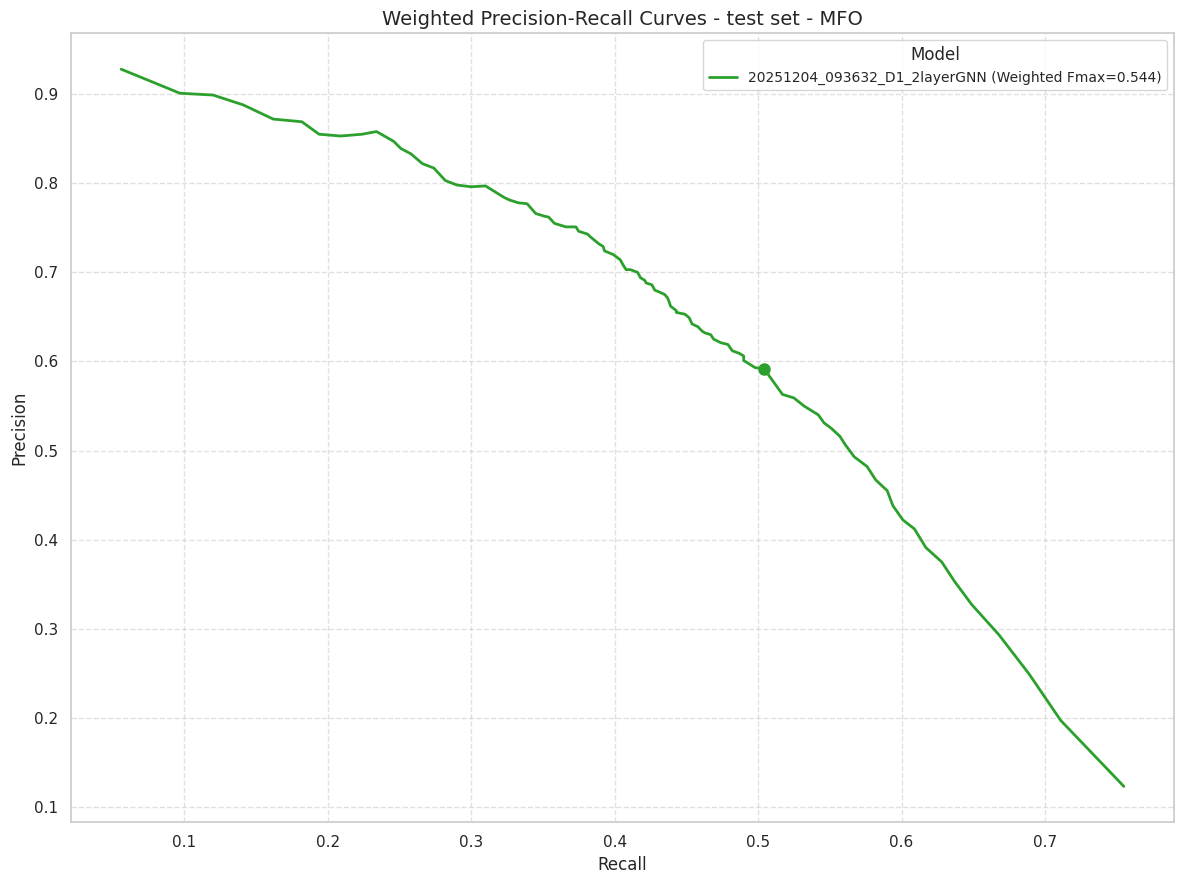

In [5]:
from matplotlib.colors import to_rgba

def load_cafa_tsv_data():
    data_list = []
    
    if not os.path.exists(GLOBAL_EVAL_DIR):
        print(f"Directory not found: {GLOBAL_EVAL_DIR}")
        return pd.DataFrame()

    try:
        models_dirs = [d for d in os.listdir(GLOBAL_EVAL_DIR) if os.path.isdir(os.path.join(GLOBAL_EVAL_DIR, d))]
    except Exception as e:
        print(e)
        return pd.DataFrame()

    for model in models_dirs:
        model_path = os.path.join(GLOBAL_EVAL_DIR, model)
        checkpoints = [d for d in os.listdir(model_path) if os.path.isdir(os.path.join(model_path, d))]
        
        for ckpt in checkpoints:
            # Path to evaluation_all.tsv
            tsv_file = os.path.join(model_path, ckpt, SPLIT, SUBONTOLOGY, "cafa-eval", "evaluation_all.tsv")
            
            if os.path.exists(tsv_file):
                try:
                    # Read TSV
                    df_res = pd.read_csv(tsv_file, sep='\t')
                    
                    # Extract Standard Metrics
                    # Fmax is max of 'f' column
                    fmax = df_res['f'].max() if 'f' in df_res.columns else 0.0
                    # Smin is min of 's' column
                    smin = df_res['s'].min() if 's' in df_res.columns else float('inf')
                    
                    # Arrays for plotting
                    # PR curve: x=Recall (rc), y=Precision (pr)
                    precisions = df_res['pr'].values if 'pr' in df_res.columns else []
                    recalls = df_res['rc'].values if 'rc' in df_res.columns else []
                    
                    # Extract Weighted Metrics if available
                    fmax_w = df_res['f_w'].max() if 'f_w' in df_res.columns else np.nan
                    precisions_w = df_res['pr_w'].values if 'pr_w' in df_res.columns else []
                    recalls_w = df_res['rc_w'].values if 'rc_w' in df_res.columns else []

                    data_list.append({
                        'Model': model,
                        'Checkpoint': ckpt,
                        'Fmax': fmax,
                        'Smin': smin,
                        'Precisions': precisions,
                        'Recalls': recalls,
                        'Fmax_w': fmax_w,
                        'Precisions_w': precisions_w,
                        'Recalls_w': recalls_w
                    })
                except Exception as e:
                    print(f"Failed to read {tsv_file}: {e}")

    return pd.DataFrame(data_list)

def plot_pr_curves(df_best, metric_type='Standard'):
    plt.figure(figsize=(12, 9))
    
    custom_colors = {
        "20251118_150705_D1_2layerGNN_CONTACT_ATTR": to_rgba("tab:blue", alpha=1.0),
        "20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR": to_rgba("tab:orange", alpha=1.0)
    }
    cmap = plt.get_cmap('tab10')
    color_idx = 2
    
    col_p = 'Precisions' if metric_type == 'Standard' else 'Precisions_w'
    col_r = 'Recalls' if metric_type == 'Standard' else 'Recalls_w'
    col_f = 'Fmax' if metric_type == 'Standard' else 'Fmax_w'
    
    for _, row in df_best.iterrows():
        p_arr = row[col_p]
        r_arr = row[col_r]
        f_val = row[col_f]
        model_name = row['Model']
        
        # Ensure arrays are not empty or None
        if isinstance(p_arr, (np.ndarray, list)) and len(p_arr) > 0:
            if model_name in custom_colors:
                color = custom_colors[model_name]
            else:
                color = cmap(color_idx % 10)
                color_idx += 1
            
            label = f"{model_name} ({metric_type} Fmax={f_val:.3f})"
            line, = plt.plot(r_arr, p_arr, label=label, linewidth=2, color=color)
            
            # Find Fmax point location on the curve
            # F = 2*p*r / (p+r)
            with np.errstate(divide='ignore', invalid='ignore'):
                f_scores = 2 * p_arr * r_arr / (p_arr + r_arr)
            f_scores = np.nan_to_num(f_scores)
            
            if len(f_scores) > 0:
                best_idx = np.argmax(f_scores)
                plt.plot(r_arr[best_idx], p_arr[best_idx], 'o', color=line.get_color(), markersize=8)

    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'{metric_type} Precision-Recall Curves - {SPLIT} set - {SUBONTOLOGY}', fontsize=14)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = [label.split('GNN_')[-1] for label in labels]
    plt.legend(handles, new_labels, title='Model', loc='best', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def main_cafa():
    df_cafa = load_cafa_tsv_data()
    
    if df_cafa.empty:
        print("No CAFA TSV data found.")
        return

    # 1. Standard Metrics Analysis
    # Select best checkpoint per model based on Standard Fmax
    df_best = df_cafa.sort_values('Fmax', ascending=False).drop_duplicates(subset='Model', keep='first')
    
    print(f"\n=== CAFA Performance Tables ({SPLIT}/{SUBONTOLOGY}) ===")
    print("\n--- Fmax (Standard) ---")
    print(df_best[['Model', 'Checkpoint', 'Fmax']].sort_values('Fmax', ascending=False).reset_index(drop=True).to_string())
    
    print("\n--- Smin (Standard) ---")
    print(df_best[['Model', 'Checkpoint', 'Smin']].sort_values('Smin', ascending=True).reset_index(drop=True).to_string())

    # Plot Standard PR Curves
    plot_pr_curves(df_best, metric_type='Standard')
    
    # 2. Weighted Metrics Analysis
    # Check if weighted data exists
    if df_cafa['Fmax_w'].notna().any():
        # Select best checkpoint per model based on Weighted Fmax for this plot
        df_best_w = df_cafa.sort_values('Fmax_w', ascending=False).drop_duplicates(subset='Model', keep='first')
        
        print("\n--- Fmax (Weighted) ---")
        print(df_best_w[['Model', 'Checkpoint', 'Fmax_w']].sort_values('Fmax_w', ascending=False).reset_index(drop=True).to_string())
        
        # Plot Weighted PR Curves
        plot_pr_curves(df_best_w, metric_type='Weighted')
    else:
        print("\nWeighted metrics (f_w, pr_w, rc_w) not found in TSV files.")

if __name__ == "__main__":
    main_cafa()

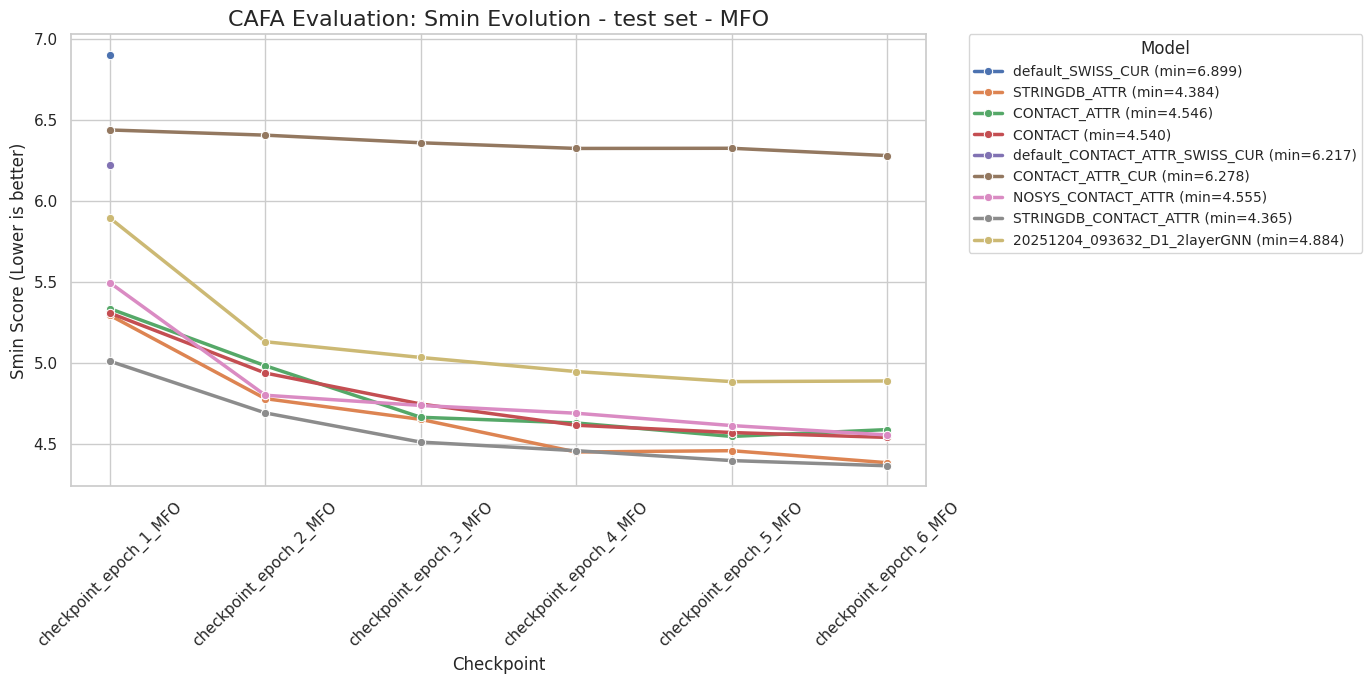

In [7]:
# Load CAFA data for evolution plotting
df_cafa_evo = load_cafa_tsv_data()

if not df_cafa_evo.empty:
    # Filter out 'latest' checkpoints to focus on epochs
    df_cafa_evo = df_cafa_evo[~df_cafa_evo['Checkpoint'].str.contains('latest', case=False, na=False)]
    df_cafa_evo = df_cafa_evo.sort_values(['Model', 'Checkpoint'])

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # Plot Smin evolution using Seaborn
    sns.lineplot(
        data=df_cafa_evo, 
        x='Checkpoint', 
        y='Smin', 
        hue='Model', 
        marker='o',
        linewidth=2.5
    )

    plt.title(f'CAFA Evaluation: Smin Evolution - {SPLIT} set - {SUBONTOLOGY}', fontsize=16)
    plt.xlabel('Checkpoint', fontsize=12)
    plt.ylabel('Smin Score (Lower is better)', fontsize=12)
    plt.xticks(rotation=45)
    
    # Simplify legend labels and add min Smin value
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = []
    for label in labels:
        # The label corresponds to the 'Model' name in the dataframe
        # Find the minimum Smin for this model
        min_val = df_cafa_evo.loc[df_cafa_evo['Model'] == label, 'Smin'].min()
        
        short_name = label.split('GNN_')[-1]
        
        if pd.notna(min_val):
            new_labels.append(f"{short_name} (min={min_val:.3f})")
        else:
            new_labels.append(short_name)

    plt.legend(handles, new_labels, title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("No CAFA data available for plotting.")

In [7]:
import pandas as pd
import os
import pickle

# Load a specific beprof_eval_results.pkl file
specific_pkl_path = "/home/atoffano/PFP_layer/results/ATGO/20251209_184526_ATGO_2layerGNN_STRINGDB_CONTACT_ATTR/evaluation/test_BPO/beprof-eval/beprof_eval_results.pkl"

if os.path.exists(specific_pkl_path):
    with open(specific_pkl_path, 'rb') as f:
        specific_result = pickle.load(f)
    print("Loaded result keys:", list(specific_result.keys()))
    print("Fmax:", specific_result.get('result_fmax'))
    print("Smin:", specific_result.get('result_smin'))
else:
    print(f"File not found: {specific_pkl_path}")

Loaded result keys: ['ontology', 'recalls', 'precisions', 'icprecisions', 'icrecalls', 'dpprecisions', 'dprecalls', 'result_aupr', 'result_icaupr', 'result_dpaupr', 'ru_values', 'mi_values', 'goic_vector', 'godp_vector', 'result_fmax', 'result_smin', 'result_t']
Fmax: 0.4176415035456693
Smin: 32.15481067797695


In [13]:
specific_result

{'ontology': 'mf',
 'recalls': array([0.        , 0.06930734, 0.11759462, 0.15001255, 0.17754756,
        0.20196602, 0.22018092, 0.23591459, 0.25415753, 0.27120986,
        0.28823344, 0.30422959, 0.3156986 , 0.33100261, 0.3413373 ,
        0.35826909, 0.36625912, 0.37875747, 0.38896363, 0.39724147,
        0.40357049, 0.41235489, 0.42028923, 0.43064362, 0.44167185,
        0.44639784, 0.45249934, 0.4566866 , 0.46171188, 0.46855156,
        0.47366167, 0.47921569, 0.48266825, 0.48702603, 0.49117485,
        0.49620524, 0.49966559, 0.5034933 , 0.50592024, 0.50835977,
        0.5125453 , 0.51589752, 0.5204846 , 0.5245676 , 0.52845767,
        0.53055144, 0.53344003, 0.53617381, 0.53888036, 0.54029932,
        0.54275292, 0.54487586, 0.54769808, 0.55097825, 0.55375867,
        0.55685236, 0.5608478 , 0.56257695, 0.56556587, 0.56866177,
        0.57078553, 0.572989  , 0.5760257 , 0.57957795, 0.58406208,
        0.58720467, 0.59056304, 0.59182436, 0.59514714, 0.59803541,
        0.60050516

In [5]:
# Load and display the evaluation_per_protein.tsv file
eval_per_protein_path = "/home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/evaluation/test_MFO/cafa-eval/evaluation_per_protein.tsv"

if os.path.exists(eval_per_protein_path):
    df_per_protein = pd.read_csv(eval_per_protein_path, sep='\t')
    display(df_per_protein)
else:
    print(f"File not found: {eval_per_protein_path}")

,tp,fp,fn,n_pred,n_gt,precision,recall,f,protein_id,ns,...,tp_w,fp_w,fn_w,n_pred_w,n_gt_w,precision_w,recall_w,f_w,tau_w,filename
0,8,9,1,17,9,0.471,0.889,0.615,5NTC_RAT,molecular_function,...,13.138,17.953,0.000,31.090,13.138,0.423,1.000,0.594,0.57,predictions.tsv
1,3,5,5,8,8,0.375,0.375,0.375,6PGL_SCHPO,molecular_function,...,3.693,7.149,16.075,10.841,19.767,0.341,0.187,0.241,0.57,predictions.tsv
2,8,18,0,26,8,0.308,1.000,0.471,AADK_BACSU,molecular_function,...,14.273,14.183,0.000,28.456,14.273,0.502,1.000,0.668,0.57,predictions.tsv
3,2,15,3,17,5,0.118,0.400,0.182,ACH2_ARATH,molecular_function,...,0.801,14.015,8.271,14.816,9.072,0.054,0.088,0.067,0.57,predictions.tsv
4,11,16,12,27,23,0.407,0.478,0.440,ADSL5_ARATH,molecular_function,...,12.396,15.293,34.049,27.689,46.445,0.448,0.267,0.334,0.57,predictions.tsv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,3,0,3,3,6,1.000,0.500,0.667,ZNG1_MOUSE,molecular_function,...,1.509,0.000,10.638,1.509,12.147,1.000,0.124,0.221,0.57,predictions.tsv
393,7,0,1,7,8,1.000,0.875,0.933,ZNG1_YEAST,molecular_function,...,9.370,0.000,1.337,9.370,10.707,1.000,0.875,0.933,0.57,predictions.tsv
394,6,6,5,12,11,0.500,0.545,0.522,ZRAP_SALTY,molecular_function,...,7.311,13.225,19.035,20.536,26.346,0.356,0.277,0.312,0.57,predictions.tsv
395,15,0,0,15,15,1.000,1.000,1.000,ZZEF1_HUMAN,molecular_function,...,15.487,0.000,0.000,15.487,15.487,1.000,1.000,1.000,0.57,predictions.tsv


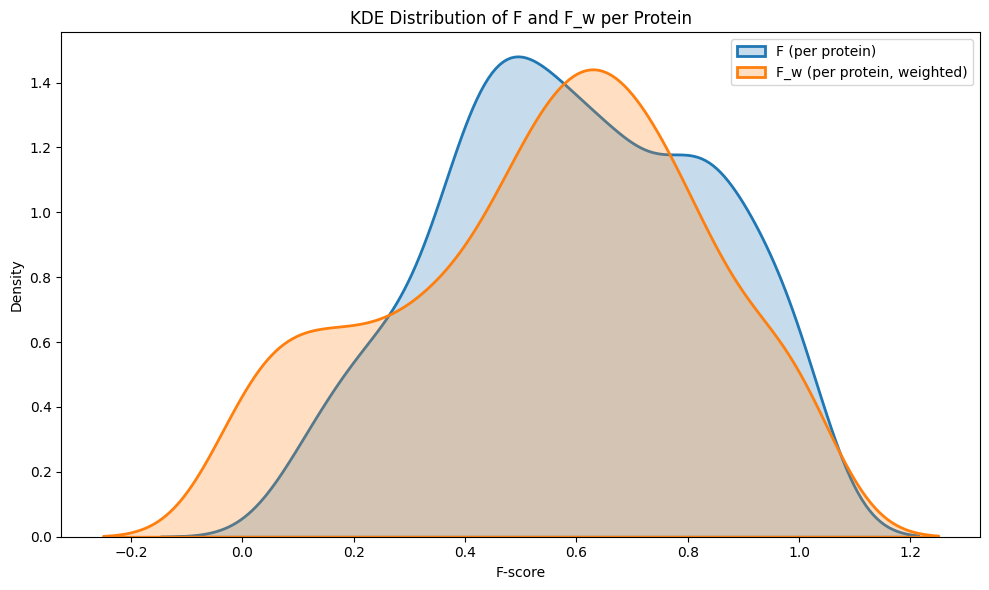

In [6]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_per_protein['f'], label='F (per protein)', fill=True, linewidth=2)
sns.kdeplot(df_per_protein['f_w'], label='F_w (per protein, weighted)', fill=True, linewidth=2)
plt.xlabel('F-score')
plt.ylabel('Density')
plt.title('KDE Distribution of F and F_w per Protein')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
%cd /home/atoffano/PFP_layer
%pwd

/home/atoffano/PFP_layer


'/home/atoffano/PFP_layer'

In [11]:
# Run CAFA evaluation with Experimental Ground Truth
!python -m src.utils.cafa_evaluation \
    --ontology /home/atoffano/PFP_layer/data/go.obo \
    --predictions /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/predictions/predictions_test_MFO.tsv \
    --ground_truth /home/atoffano/PFP_layer/data/D1/D1_MFO_test_exp_annotations.tsv \
    --ia /home/atoffano/PFP_layer/data/D1/IA_D1_MFO.tsv \
    --per_protein \
    --output /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/evaluation/test_MFO_exp/cafa-eval

2025-12-19 09:59:53,575 - INFO - Using intermediate directory: /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/evaluation/test_MFO_exp/cafa-eval/cafa_inputs
2025-12-19 09:59:53,575 - INFO - Loading predictions from /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/predictions/predictions_test_MFO.tsv
2025-12-19 10:00:06,989 - INFO - Saved 5070828 predictions to /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/evaluation/test_MFO_exp/cafa-eval/cafa_inputs/predictions/predictions.tsv
2025-12-19 10:00:07,025 - INFO - Loading ground truth from /home/atoffano/PFP_layer/data/D1/D1_MFO_test_exp_annotations.tsv
2025-12-19 10:00:07,037 - INFO - Saved 3585 ground truth annotations to /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/evaluation/test_MFO_exp/cafa-eval/cafa_inputs/ground_truth.tsv
2025-12-19 10:00:07,037 - INFO - Running CAFA evaluation...
2025-12-19 10

In [12]:
# Load Experimental Results
exp_eval_path = "/home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/evaluation/test_MFO_exp/cafa-eval/evaluation_per_protein.tsv"
if os.path.exists(exp_eval_path):
    df_exp = pd.read_csv(exp_eval_path, sep='\t')
    print(f"Loaded Experimental Results: {len(df_exp)} proteins")
    display(df_exp.head())
else:
    print(f"File not found: {exp_eval_path}")


Loaded Experimental Results: 397 proteins


,tp,fp,fn,n_pred,n_gt,precision,recall,f,protein_id,ns,...,tp_w,fp_w,fn_w,n_pred_w,n_gt_w,precision_w,recall_w,f_w,tau_w,filename
0,8,9,1,17,9,0.471,0.889,0.615,5NTC_RAT,molecular_function,...,13.138,17.953,0.000,31.090,13.138,0.423,1.000,0.594,0.57,predictions.tsv
1,3,5,5,8,8,0.375,0.375,0.375,6PGL_SCHPO,molecular_function,...,3.693,7.149,16.075,10.841,19.767,0.341,0.187,0.241,0.57,predictions.tsv
2,8,18,0,26,8,0.308,1.000,0.471,AADK_BACSU,molecular_function,...,14.273,14.183,0.000,28.456,14.273,0.502,1.000,0.668,0.57,predictions.tsv
3,2,15,3,17,5,0.118,0.400,0.182,ACH2_ARATH,molecular_function,...,0.801,14.015,8.271,14.816,9.072,0.054,0.088,0.067,0.57,predictions.tsv
4,11,16,12,27,23,0.407,0.478,0.440,ADSL5_ARATH,molecular_function,...,12.396,15.293,34.049,27.689,46.445,0.448,0.267,0.334,0.57,predictions.tsv


In [13]:
# Run CAFA evaluation with Curated Ground Truth
!python -m src.utils.cafa_evaluation \
    --ontology /home/atoffano/PFP_layer/data/go.obo \
    --predictions /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/predictions/predictions_test_MFO.tsv \
    --ground_truth /home/atoffano/PFP_layer/data/D1/D1_MFO_test_cur_annotations.tsv \
    --ia /home/atoffano/PFP_layer/data/D1/IA_D1_MFO.tsv \
    --per_protein \
    --output /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/evaluation/test_MFO_cur/cafa-eval

2025-12-19 10:00:23,132 - INFO - Using intermediate directory: /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/evaluation/test_MFO_cur/cafa-eval/cafa_inputs
2025-12-19 10:00:23,132 - INFO - Loading predictions from /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/predictions/predictions_test_MFO.tsv
2025-12-19 10:00:36,598 - INFO - Saved 5070828 predictions to /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/evaluation/test_MFO_cur/cafa-eval/cafa_inputs/predictions/predictions.tsv
2025-12-19 10:00:36,632 - INFO - Loading ground truth from /home/atoffano/PFP_layer/data/D1/D1_MFO_test_cur_annotations.tsv
2025-12-19 10:00:36,649 - INFO - Saved 6546 ground truth annotations to /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/evaluation/test_MFO_cur/cafa-eval/cafa_inputs/ground_truth.tsv
2025-12-19 10:00:36,650 - INFO - Running CAFA evaluation...
2025-12-19 10

In [14]:
# Load Curated Results
cur_eval_path = "/home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/evaluation/test_MFO_cur/cafa-eval/evaluation_per_protein.tsv"
if os.path.exists(cur_eval_path):
    df_cur = pd.read_csv(cur_eval_path, sep='\t')
    print(f"Loaded Curated Results: {len(df_cur)} proteins")
    display(df_cur.head())
else:
    print(f"File not found: {cur_eval_path}")


Loaded Curated Results: 401 proteins


,tp,fp,fn,n_pred,n_gt,precision,recall,f,protein_id,ns,...,tp_w,fp_w,fn_w,n_pred_w,n_gt_w,precision_w,recall_w,f_w,tau_w,filename
0,5,5,0,10,5,0.5,1.000,0.667,5NTC_RAT,molecular_function,...,8.726,15.74,0.000,24.466,8.726,0.357,1.000,0.526,0.41,predictions.tsv
1,14,0,2,14,16,1.0,0.875,0.933,6PGL_SCHPO,molecular_function,...,24.036,0.00,5.240,24.036,29.276,1.000,0.821,0.902,0.41,predictions.tsv
2,26,0,0,26,26,1.0,1.000,1.000,AADK_BACSU,molecular_function,...,18.557,0.00,0.000,18.557,18.557,1.000,1.000,1.000,0.41,predictions.tsv
3,11,0,2,11,13,1.0,0.846,0.917,ACH2_ARATH,molecular_function,...,18.616,0.00,2.874,18.616,21.491,1.000,0.866,0.928,0.41,predictions.tsv
4,28,0,12,28,40,1.0,0.700,0.824,ADSL5_ARATH,molecular_function,...,32.990,0.00,30.312,32.990,63.302,1.000,0.521,0.685,0.41,predictions.tsv


In [15]:
# Run CAFA evaluation with Experimental Ground Truth - EXP model
!python -m src.utils.cafa_evaluation \
    --ontology /home/atoffano/PFP_layer/data/go.obo \
    --predictions /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/predictions/predictions_test_MFO.tsv \
    --ground_truth /home/atoffano/PFP_layer/data/D1/D1_MFO_test_exp_annotations.tsv \
    --ia /home/atoffano/PFP_layer/data/D1/IA_D1_MFO.tsv \
    --per_protein \
    --output /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/evaluation/test_MFO_exp/cafa-eval

2025-12-19 10:00:53,655 - INFO - Using intermediate directory: /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/evaluation/test_MFO_exp/cafa-eval/cafa_inputs
2025-12-19 10:00:53,655 - INFO - Loading predictions from /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/predictions/predictions_test_MFO.tsv
2025-12-19 10:01:07,105 - INFO - Saved 5070828 predictions to /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/evaluation/test_MFO_exp/cafa-eval/cafa_inputs/predictions/predictions.tsv
2025-12-19 10:01:07,139 - INFO - Loading ground truth from /home/atoffano/PFP_layer/data/D1/D1_MFO_test_exp_annotations.tsv
2025-12-19 10:01:07,153 - INFO - Saved 3585 ground truth annotations to /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/evaluation/test_MFO_exp/cafa-eval/cafa_inputs/ground_truth.tsv
2025-12-19 10:01:07,153 - INFO - Running CAFA evaluation...
2025-12-19 10:01:07,153 - INF

In [16]:
# Load Results
exp_eval_path = "/home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/evaluation/test_MFO_exp/cafa-eval/evaluation_per_protein.tsv"
if os.path.exists(exp_eval_path):
    df_exp_expmodel = pd.read_csv(exp_eval_path, sep='\t')
    print(f"Loaded Experimental Results: {len(df_exp_expmodel)} proteins")
    display(df_exp_expmodel.head())
else:
    print(f"File not found: {exp_eval_path}")

Loaded Experimental Results: 397 proteins


,tp,fp,fn,n_pred,n_gt,precision,recall,f,protein_id,ns,...,tp_w,fp_w,fn_w,n_pred_w,n_gt_w,precision_w,recall_w,f_w,tau_w,filename
0,6,0,3,6,9,1.000,0.667,0.800,5NTC_RAT,molecular_function,...,6.936,0.000,6.202,6.936,13.138,1.000,0.528,0.691,0.41,predictions.tsv
1,3,7,5,10,8,0.300,0.375,0.333,6PGL_SCHPO,molecular_function,...,3.693,13.745,16.075,17.437,19.767,0.212,0.187,0.199,0.41,predictions.tsv
2,8,2,0,10,8,0.800,1.000,0.889,AADK_BACSU,molecular_function,...,14.273,2.311,0.000,16.584,14.273,0.861,1.000,0.925,0.41,predictions.tsv
3,2,10,3,12,5,0.167,0.400,0.235,ACH2_ARATH,molecular_function,...,0.801,9.891,8.271,10.693,9.072,0.075,0.088,0.081,0.41,predictions.tsv
4,9,0,14,9,23,1.000,0.391,0.562,ADSL5_ARATH,molecular_function,...,10.887,0.000,35.558,10.887,46.445,1.000,0.234,0.380,0.41,predictions.tsv


In [17]:
# Run CAFA evaluation with Curated Ground Truth - EXP model
!python -m src.utils.cafa_evaluation \
    --ontology /home/atoffano/PFP_layer/data/go.obo \
    --predictions /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/predictions/predictions_test_MFO.tsv \
    --ground_truth /home/atoffano/PFP_layer/data/D1/D1_MFO_test_cur_annotations.tsv \
    --ia /home/atoffano/PFP_layer/data/D1/IA_D1_MFO.tsv \
    --per_protein \
    --output /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/evaluation/test_MFO_cur/cafa-eval


2025-12-19 10:01:23,727 - INFO - Using intermediate directory: /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/evaluation/test_MFO_cur/cafa-eval/cafa_inputs
2025-12-19 10:01:23,727 - INFO - Loading predictions from /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/predictions/predictions_test_MFO.tsv
2025-12-19 10:01:37,259 - INFO - Saved 5070828 predictions to /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/evaluation/test_MFO_cur/cafa-eval/cafa_inputs/predictions/predictions.tsv
2025-12-19 10:01:37,295 - INFO - Loading ground truth from /home/atoffano/PFP_layer/data/D1/D1_MFO_test_cur_annotations.tsv
2025-12-19 10:01:37,310 - INFO - Saved 6546 ground truth annotations to /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/evaluation/test_MFO_cur/cafa-eval/cafa_inputs/ground_truth.tsv
2025-12-19 10:01:37,310 - INFO - Running CAFA evaluation...
2025-12-19 10:01:37,310 - INF

In [18]:
# Load Results
cur_eval_path = "/home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/evaluation/test_MFO_cur/cafa-eval/evaluation_per_protein.tsv"
if os.path.exists(cur_eval_path):
    df_cur_expmodel = pd.read_csv(cur_eval_path, sep='\t')
    print(f"Loaded Experimental Results: {len(df_cur_expmodel)} proteins")
    display(df_cur_expmodel.head())
else:
    print(f"File not found: {cur_eval_path}")

Loaded Experimental Results: 401 proteins


,tp,fp,fn,n_pred,n_gt,precision,recall,f,protein_id,ns,...,tp_w,fp_w,fn_w,n_pred_w,n_gt_w,precision_w,recall_w,f_w,tau_w,filename
0,5,5,0,10,5,0.500,1.000,0.667,5NTC_RAT,molecular_function,...,8.726,15.740,0.000,24.466,8.726,0.357,1.000,0.526,0.13,predictions.tsv
1,11,6,5,17,16,0.647,0.688,0.667,6PGL_SCHPO,molecular_function,...,19.705,13.033,9.571,32.738,29.276,0.602,0.673,0.635,0.13,predictions.tsv
2,20,0,6,20,26,1.000,0.769,0.870,AADK_BACSU,molecular_function,...,16.008,2.823,2.549,18.832,18.557,0.850,0.863,0.856,0.13,predictions.tsv
3,5,0,8,5,13,1.000,0.385,0.556,ACH2_ARATH,molecular_function,...,10.495,0.000,10.996,10.495,21.491,1.000,0.488,0.656,0.13,predictions.tsv
4,11,0,29,11,40,1.000,0.275,0.431,ADSL5_ARATH,molecular_function,...,12.396,0.000,50.906,12.396,63.302,1.000,0.196,0.328,0.13,predictions.tsv


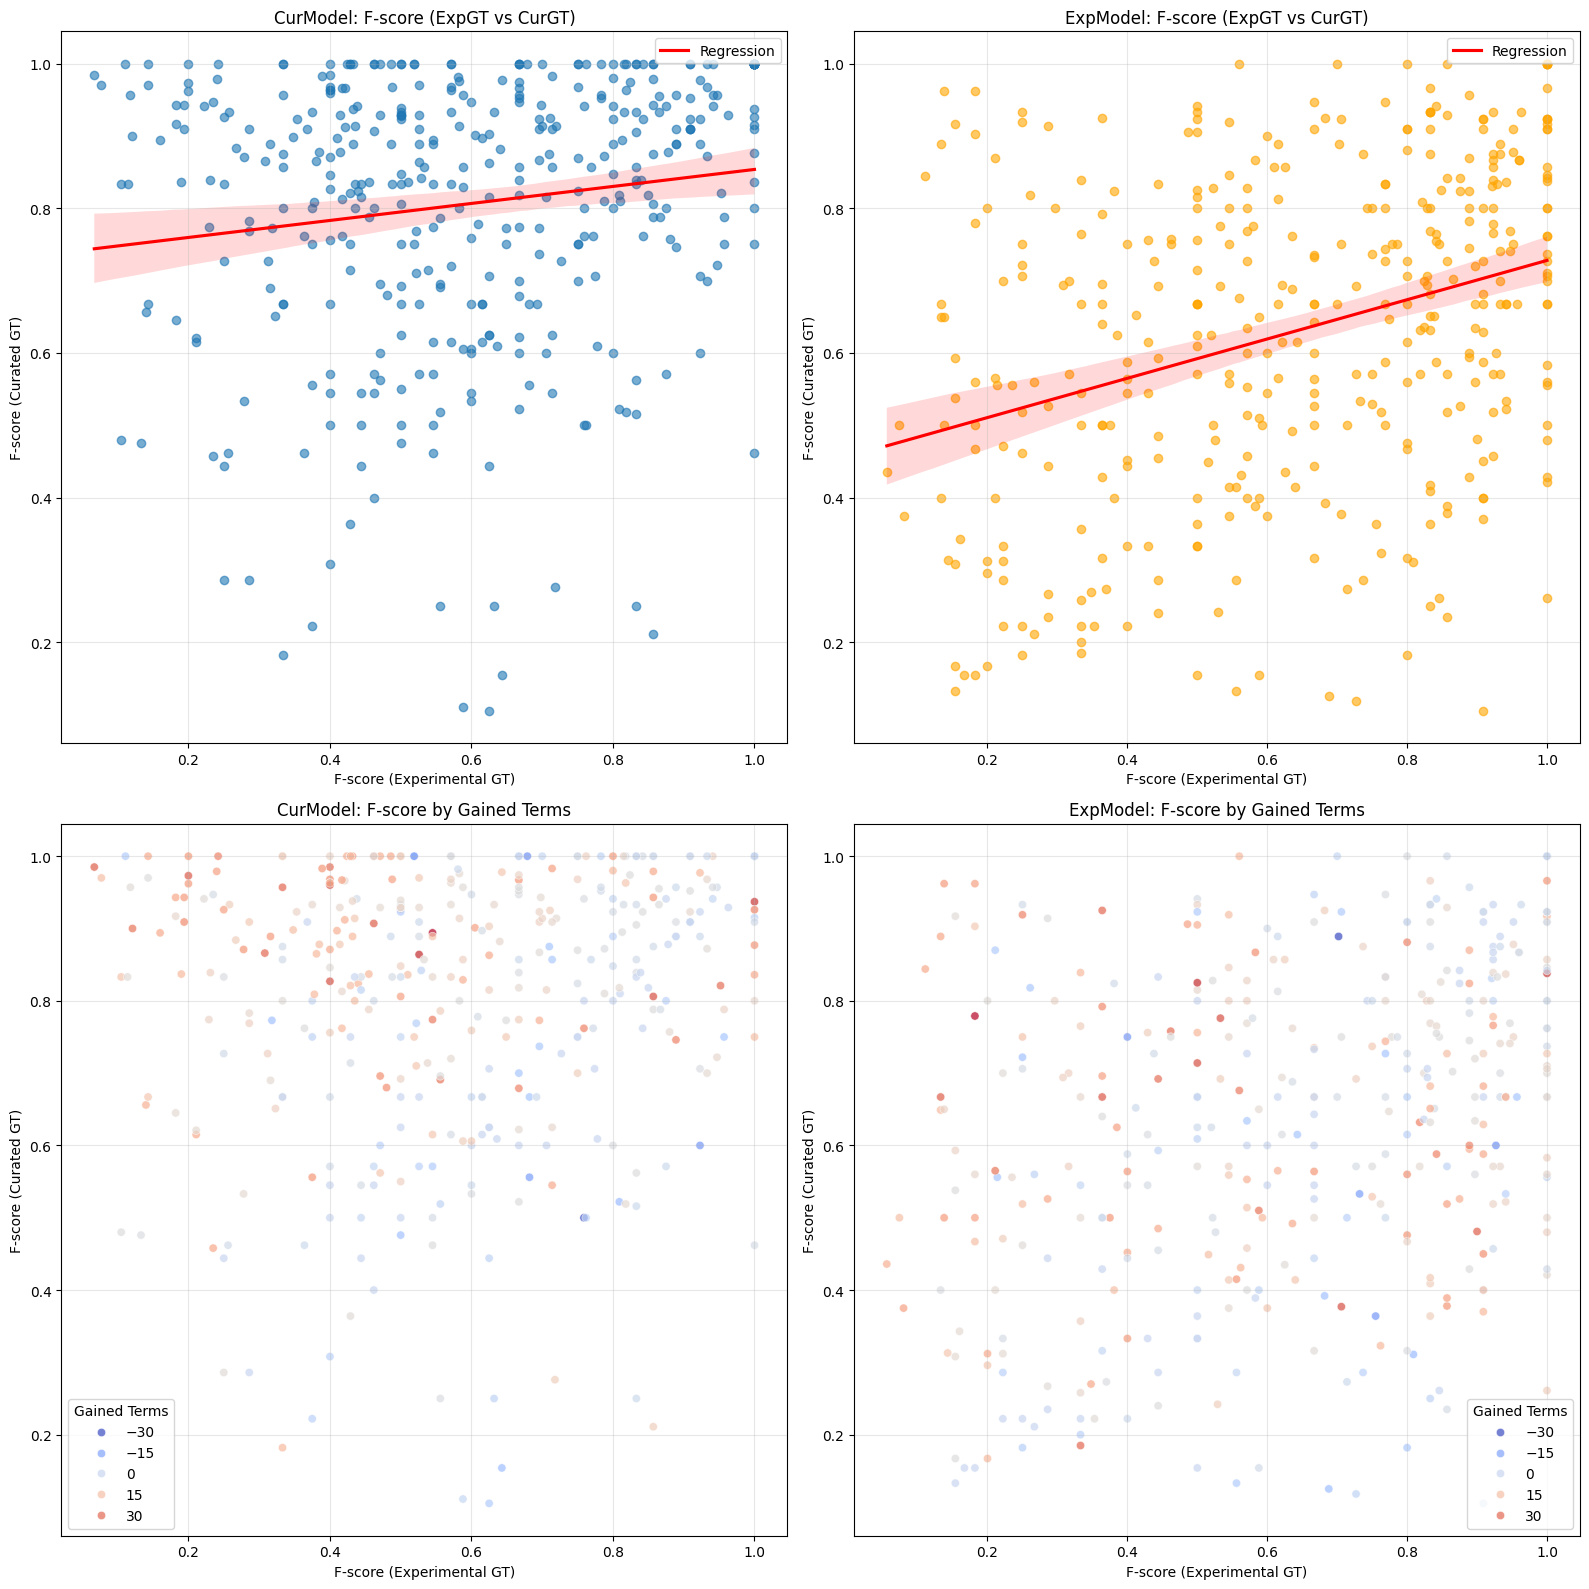

In [19]:
from functools import reduce

# Rename columns to avoid collisions and make merging easier
cols = ['protein_id', 'f', 'n_gt', 'tau']

# df_exp: CurModel on ExpGT
d1 = df_exp[cols].rename(columns=lambda x: x + '_expgt_curmodel' if x != 'protein_id' else x)
# df_cur: CurModel on CurGT
d2 = df_cur[cols].rename(columns=lambda x: x + '_curgt_curmodel' if x != 'protein_id' else x)
# df_cur_expmodel: ExpModel on CurGT
d3 = df_cur_expmodel[cols].rename(columns=lambda x: x + '_curgt_expmodel' if x != 'protein_id' else x)
# df_exp_expmodel: ExpModel on ExpGT
d4 = df_exp_expmodel[cols].rename(columns=lambda x: x + '_expgt_expmodel' if x != 'protein_id' else x)

df_merged = reduce(lambda left, right: pd.merge(left, right, on='protein_id', how='inner'), [d1, d2, d3, d4])

# Calculate gained terms (Curated GT count - Experimental GT count)
df_merged['gained_terms'] = df_merged['n_gt_curgt_curmodel'] - df_merged['n_gt_expgt_curmodel']

# Scatter plot comparing F-score (Experimental vs Curated) for all proteins
plt.figure(figsize=(16, 16))

# Plot 1: CurModel - ExpGT vs CurGT (Regression)
plt.subplot(2, 2, 1)
sns.regplot(data=df_merged, x='f_expgt_curmodel', y='f_curgt_curmodel', scatter_kws={'alpha':0.6}, line_kws={'color': 'red', 'label': 'Regression'})
plt.title('CurModel: F-score (ExpGT vs CurGT)')
plt.xlabel('F-score (Experimental GT)')
plt.ylabel('F-score (Curated GT)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: ExpModel - ExpGT vs CurGT (Regression)
plt.subplot(2, 2, 2)
sns.regplot(data=df_merged, x='f_expgt_expmodel', y='f_curgt_expmodel', scatter_kws={'alpha':0.6, 'color': 'orange'}, line_kws={'color': 'red', 'label': 'Regression'})
plt.title('ExpModel: F-score (ExpGT vs CurGT)')
plt.xlabel('F-score (Experimental GT)')
plt.ylabel('F-score (Curated GT)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: CurModel - ExpGT vs CurGT (Colored by Gained Terms)
plt.subplot(2, 2, 3)
sns.scatterplot(data=df_merged, x='f_expgt_curmodel', y='f_curgt_curmodel', hue='gained_terms', palette='coolwarm', alpha=0.7)
plt.title('CurModel: F-score by Gained Terms')
plt.xlabel('F-score (Experimental GT)')
plt.ylabel('F-score (Curated GT)')
plt.legend(title='Gained Terms')
plt.grid(True, alpha=0.3)

# Plot 4: ExpModel - ExpGT vs CurGT (Colored by Gained Terms)
plt.subplot(2, 2, 4)
sns.scatterplot(data=df_merged, x='f_expgt_expmodel', y='f_curgt_expmodel', hue='gained_terms', palette='coolwarm', alpha=0.7)
plt.title('ExpModel: F-score by Gained Terms')
plt.xlabel('F-score (Experimental GT)')
plt.ylabel('F-score (Curated GT)')
plt.legend(title='Gained Terms')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
import subprocess

# Select bottom 10 proteins based on Exp F-score (CurModel)
bottom_10_df = df_merged.sort_values('f_expgt_curmodel').head(10)

print("--- Bottom 10 Proteins Analysis ---")
display(bottom_10_df[['protein_id', 'f_expgt_curmodel', 'f_curgt_curmodel', 'f_expgt_expmodel', 'f_curgt_expmodel']])

# Paths
pred_file_curmodel = "/home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/predictions/predictions_test_MFO.tsv"
pred_file_expmodel = "/home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/predictions/predictions_test_MFO.tsv"

obo_file = "/home/atoffano/PFP_layer/data/go.obo"
gt_exp_file = "/home/atoffano/PFP_layer/data/D1/D1_MFO_test_exp_annotations.tsv"
gt_cur_file = "/home/atoffano/PFP_layer/data/D1/D1_MFO_test_cur_annotations.tsv"

# Generate plots for each protein
for _, row in bottom_10_df.iterrows():
    pid = row['protein_id']
    
    # Taus for each model/GT combination
    tau_cur_exp = row['tau_expgt_curmodel']
    tau_cur_cur = row['tau_curgt_curmodel']
    tau_exp_exp = row['tau_expgt_expmodel']
    tau_exp_cur = row['tau_curgt_expmodel']
    
    print(f"\nProcessing {pid}...")
    
    # Plot with Experimental GT (Comparing both models)
    cmd_exp = [
        "python", "-m", "src.utils.compare_methods",
        "--pred", pred_file_curmodel, str(tau_cur_exp), "CurModel",
        "--pred", pred_file_expmodel, str(tau_exp_exp), "ExpModel",
        "--gt", gt_exp_file,
        "--obo", obo_file,
        "--protein", pid
    ]
    
    # Plot with Curated GT (Comparing both models)
    cmd_cur = [
        "python", "-m", "src.utils.compare_methods",
        "--pred", pred_file_curmodel, str(tau_cur_cur), "CurModel",
        "--pred", pred_file_expmodel, str(tau_exp_cur), "ExpModel",
        "--gt", gt_cur_file,
        "--obo", obo_file,
        "--protein", pid
    ]
    
    # Run commands
    print(f"  Generating plot for Exp GT...")
    subprocess.run(cmd_exp, check=True)
    if os.path.exists(f"pred_{pid}.png"):
        os.rename(f"pred_{pid}.png", f"pred_{pid}_exp.png")
        
    print(f"  Generating plot for Cur GT...")
    subprocess.run(cmd_cur, check=True)
    if os.path.exists(f"pred_{pid}.png"):
        os.rename(f"pred_{pid}.png", f"pred_{pid}_cur.png")

print("\nDone generating plots.")

--- Bottom 10 Proteins Analysis ---


,protein_id,f_expgt_curmodel,f_curgt_curmodel,f_expgt_expmodel,f_curgt_expmodel
137,GHC1_RAT,0.067,0.985,0.133,0.667
97,ERG13_SCHPO,0.077,0.970,0.074,0.500
158,HYBD_ECOLI,0.105,0.480,0.154,0.167
280,RETR3_MOUSE,0.105,0.833,0.250,0.750
251,PMGE_MOUSE,0.111,1.000,0.211,0.870
331,TAL1_SCHPO,0.114,0.833,0.250,0.462
272,PXP1_SCHPO,0.118,0.957,0.154,0.917
388,ZN592_MOUSE,0.121,0.900,0.211,0.565
288,RS31_CANAL,0.133,0.476,0.133,0.400
69,DHRS6_HUMAN,0.140,0.656,0.056,0.436



Processing GHC1_RAT...
  Generating plot for Exp GT...
Loading ontology with go3...
Parsing ground truth...
Found 10 terms in GT.
Parsing predictions from /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/predictions/predictions_test_MFO.tsv with threshold 0.66...
Parsing predictions from /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/predictions/predictions_test_MFO.tsv with threshold 0.41...
Building subgraph...
Subgraph contains 20 nodes and 23 edges.
Plotting...


/home/atoffano/PFP_layer/src/utils/compare_methods.py:375: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  markerfacecolor=cm.get_cmap(pred_cmaps[i])(0.8),


Saved GO multi-prediction+GT graph to pred_GHC1_RAT.png
  Generating plot for Cur GT...
Loading ontology with go3...
Parsing ground truth...
Found 23 terms in GT.
Parsing predictions from /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/predictions/predictions_test_MFO.tsv with threshold 0.49...
Parsing predictions from /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/predictions/predictions_test_MFO.tsv with threshold 0.16...
Building subgraph...
Subgraph contains 29 nodes and 39 edges.
Plotting...


...

Saved GO multi-prediction+GT graph to pred_RS31_CANAL.png

Processing DHRS6_HUMAN...
  Generating plot for Exp GT...
Loading ontology with go3...
Parsing ground truth...
Found 15 terms in GT.
Parsing predictions from /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/predictions/predictions_test_MFO.tsv with threshold 0.66...
Parsing predictions from /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/predictions/predictions_test_MFO.tsv with threshold 0.41...
Building subgraph...
Subgraph contains 18 nodes and 18 edges.
Plotting...


/home/atoffano/PFP_layer/src/utils/compare_methods.py:375: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  markerfacecolor=cm.get_cmap(pred_cmaps[i])(0.8),


Saved GO multi-prediction+GT graph to pred_DHRS6_HUMAN.png
  Generating plot for Cur GT...
Loading ontology with go3...
Parsing ground truth...
Found 18 terms in GT.
Parsing predictions from /home/atoffano/PFP_layer/results/D1/20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR/predictions/predictions_test_MFO.tsv with threshold 0.49...
Parsing predictions from /home/atoffano/PFP_layer/results/D1/20251118_150705_D1_2layerGNN_CONTACT_ATTR/predictions/predictions_test_MFO.tsv with threshold 0.16...
Building subgraph...
Subgraph contains 29 nodes and 30 edges.
Plotting...


/home/atoffano/PFP_layer/src/utils/compare_methods.py:375: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  markerfacecolor=cm.get_cmap(pred_cmaps[i])(0.8),


Saved GO multi-prediction+GT graph to pred_DHRS6_HUMAN.png

Done generating plots.


In [36]:
bottom_10_df

,protein_id,f_expgt_curmodel,n_gt_expgt_curmodel,tau_expgt_curmodel,f_curgt_curmodel,n_gt_curgt_curmodel,tau_curgt_curmodel,f_curgt_expmodel,n_gt_curgt_expmodel,tau_curgt_expmodel,f_expgt_expmodel,n_gt_expgt_expmodel,tau_expgt_expmodel,gained_terms,f_gain
137,GHC1_RAT,0.067,2,0.66,0.985,33,0.49,0.667,33,0.16,0.133,2,0.41,31,0.534
97,ERG13_SCHPO,0.077,17,0.66,0.970,32,0.49,0.500,32,0.16,0.074,17,0.41,15,0.426
158,HYBD_ECOLI,0.105,6,0.66,0.480,11,0.49,0.167,11,0.16,0.154,6,0.41,5,0.013
280,RETR3_MOUSE,0.105,6,0.66,0.833,20,0.49,0.750,20,0.16,0.250,6,0.41,14,0.500
251,PMGE_MOUSE,0.111,17,0.66,1.000,12,0.49,0.870,12,0.16,0.211,17,0.41,-5,0.659
331,TAL1_SCHPO,0.114,4,0.66,0.833,10,0.49,0.462,10,0.16,0.250,4,0.41,6,0.212
272,PXP1_SCHPO,0.118,6,0.66,0.957,12,0.49,0.917,12,0.16,0.154,6,0.41,6,0.763
388,ZN592_MOUSE,0.121,5,0.66,0.900,33,0.49,0.565,33,0.16,0.211,5,0.41,28,0.354
288,RS31_CANAL,0.133,3,0.66,0.476,7,0.49,0.400,7,0.16,0.133,3,0.41,4,0.267
69,DHRS6_HUMAN,0.140,25,0.66,0.656,43,0.49,0.436,43,0.16,0.056,25,0.41,18,0.380


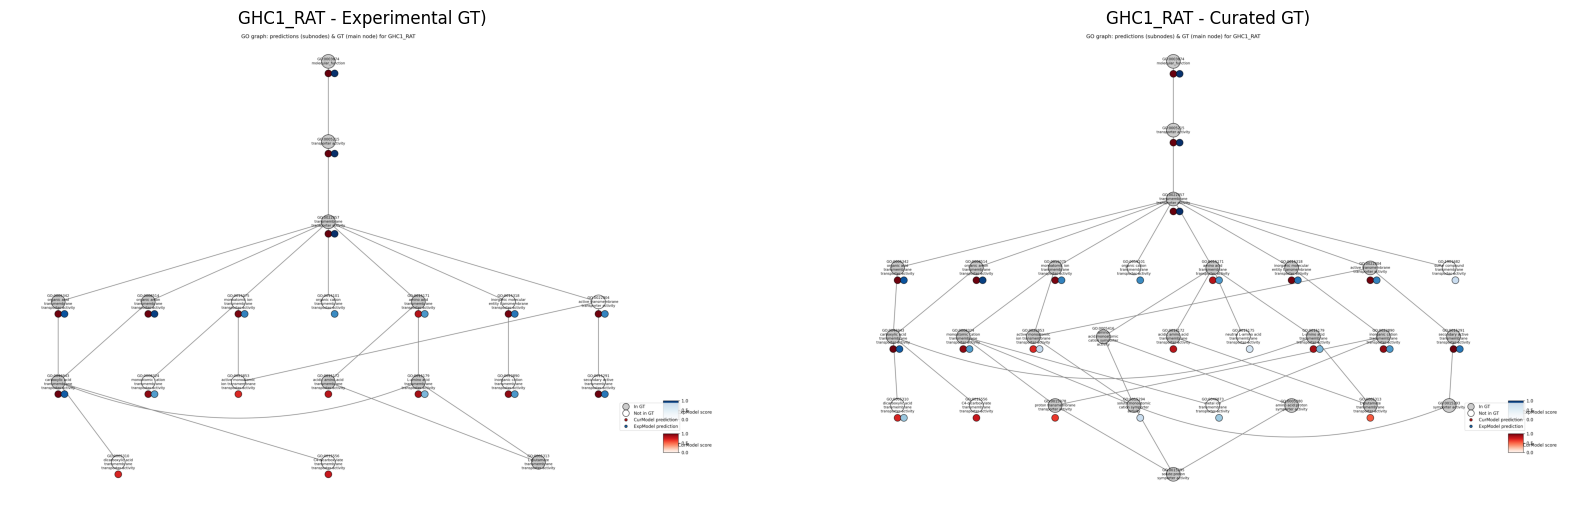

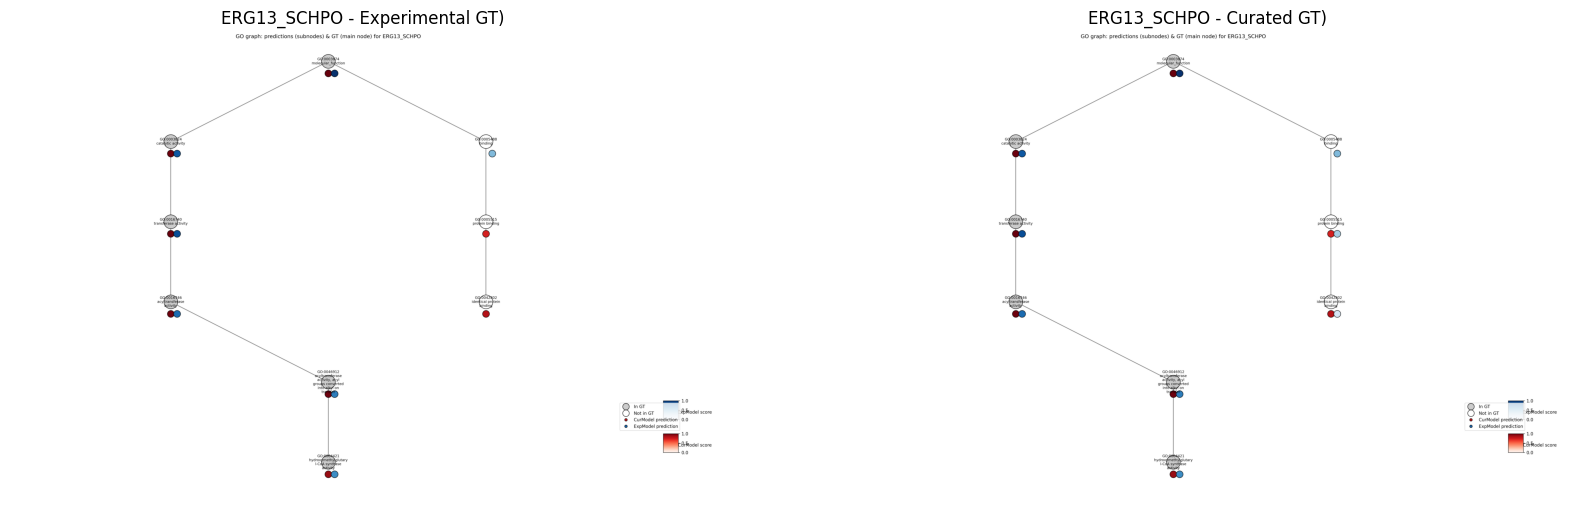

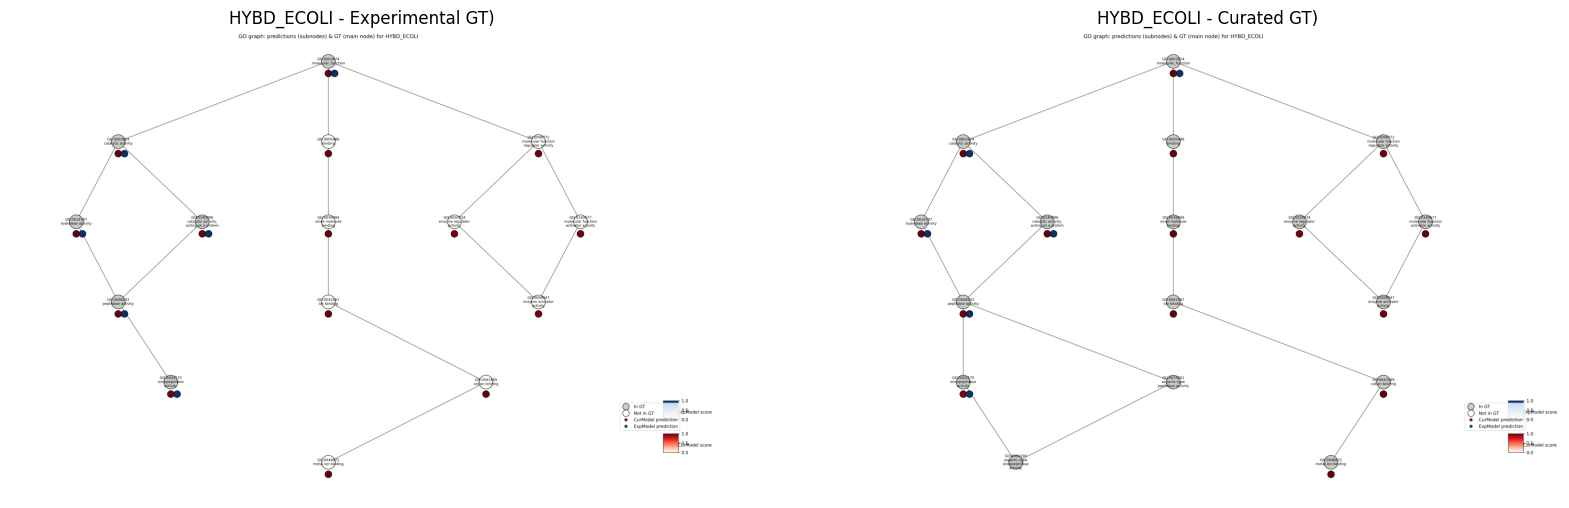

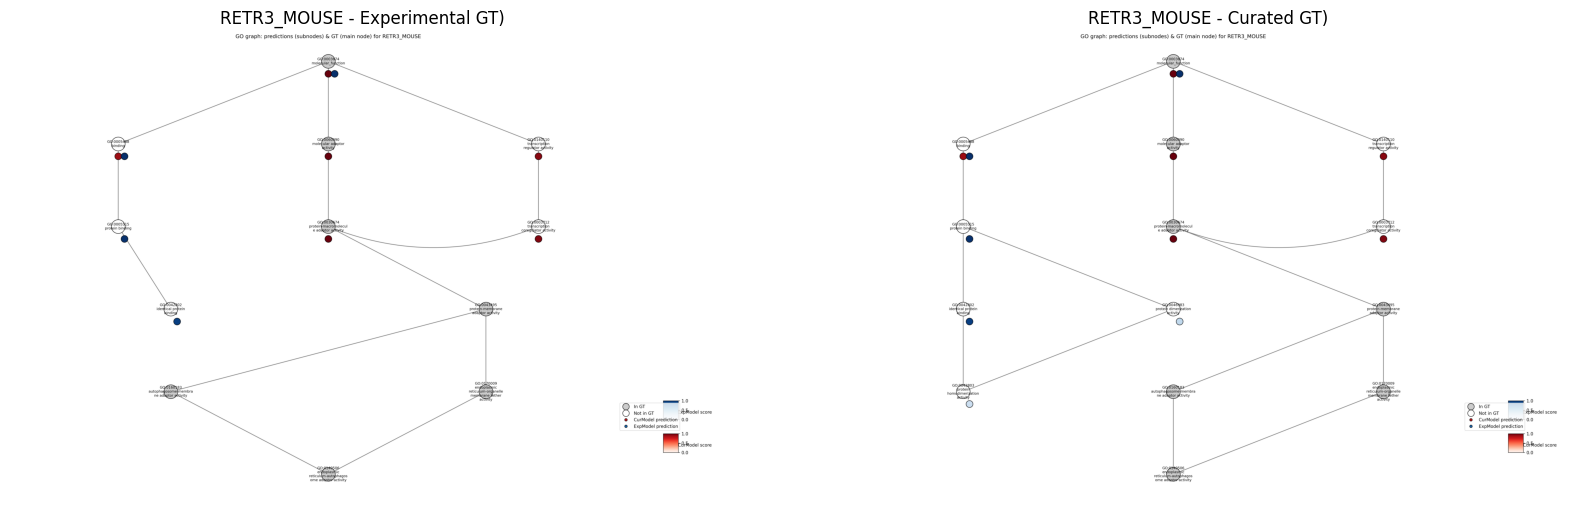

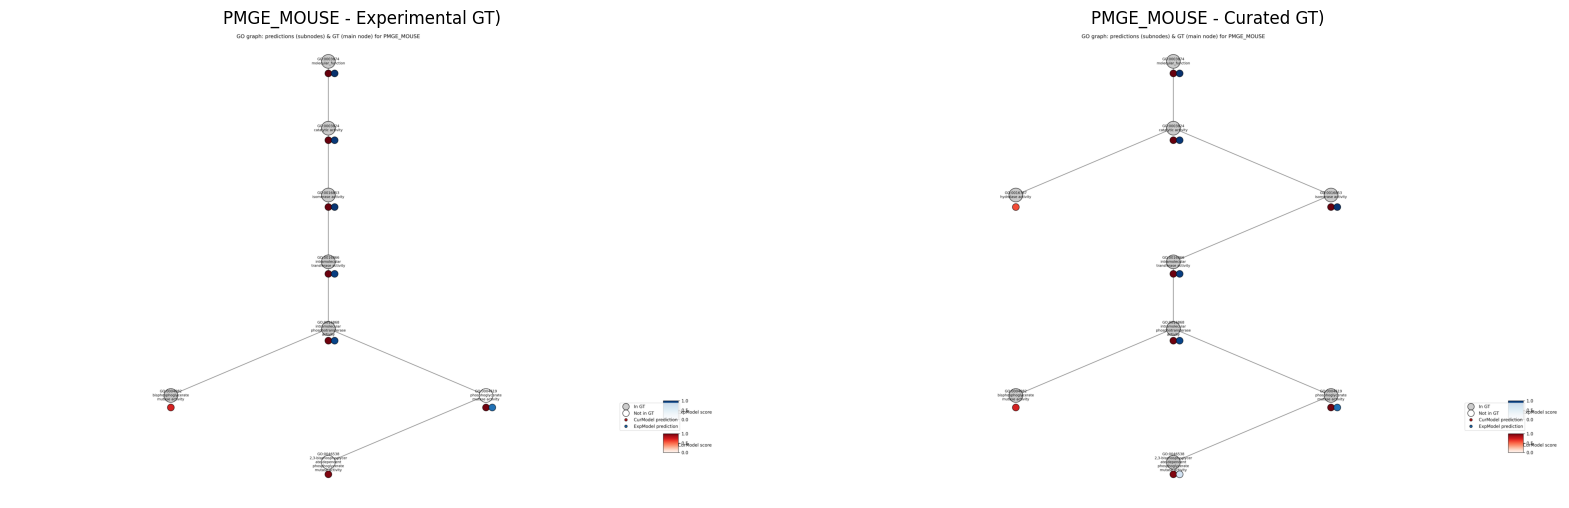

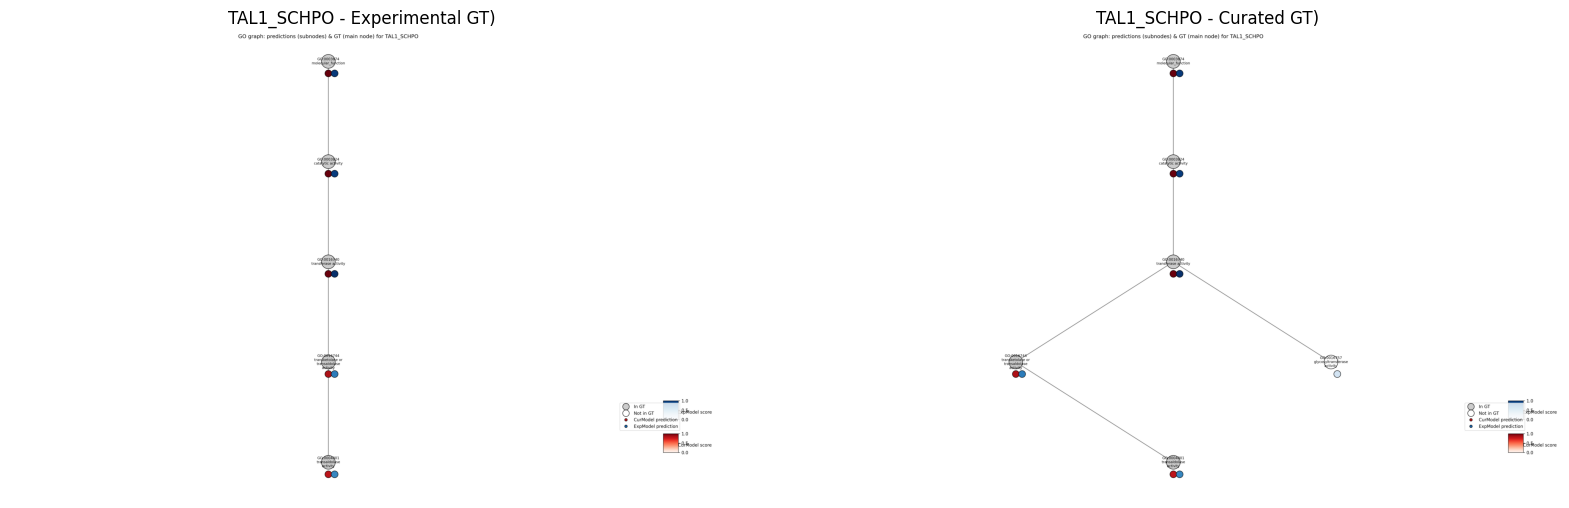

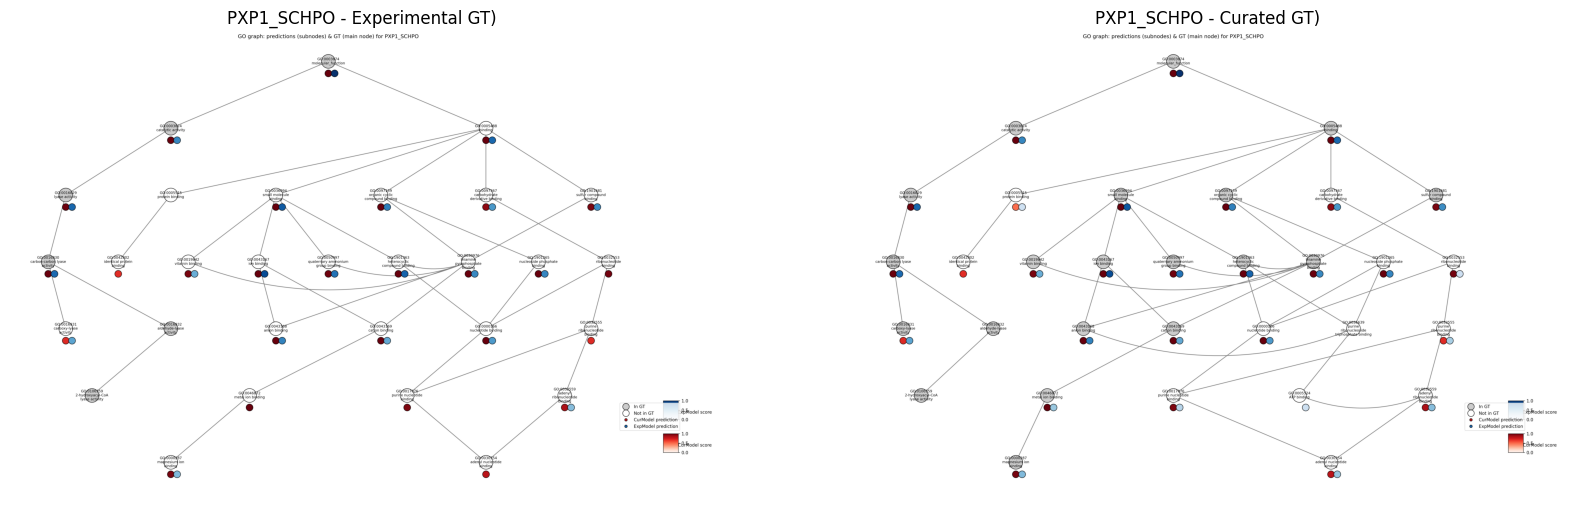

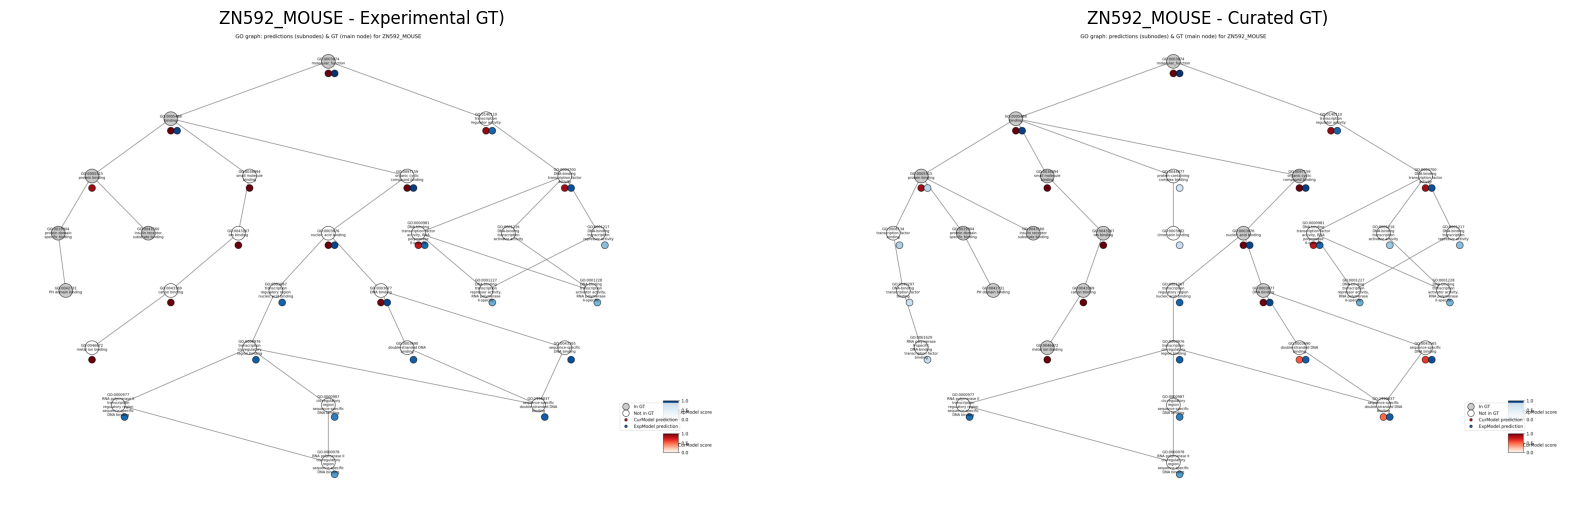

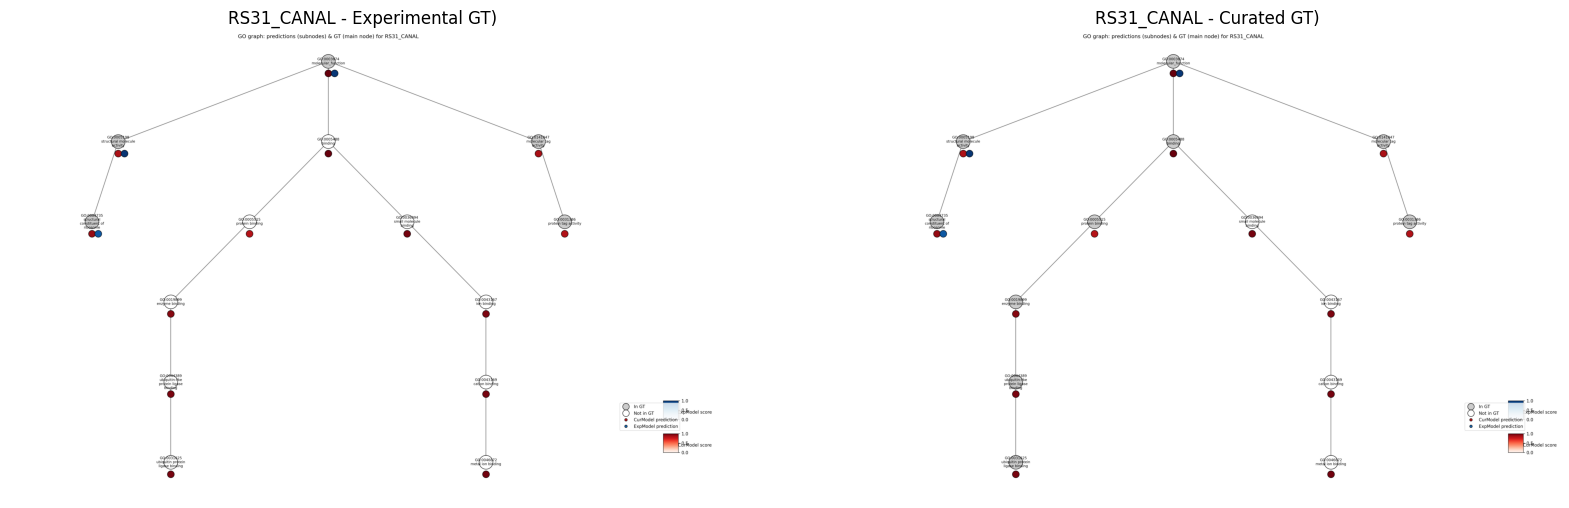

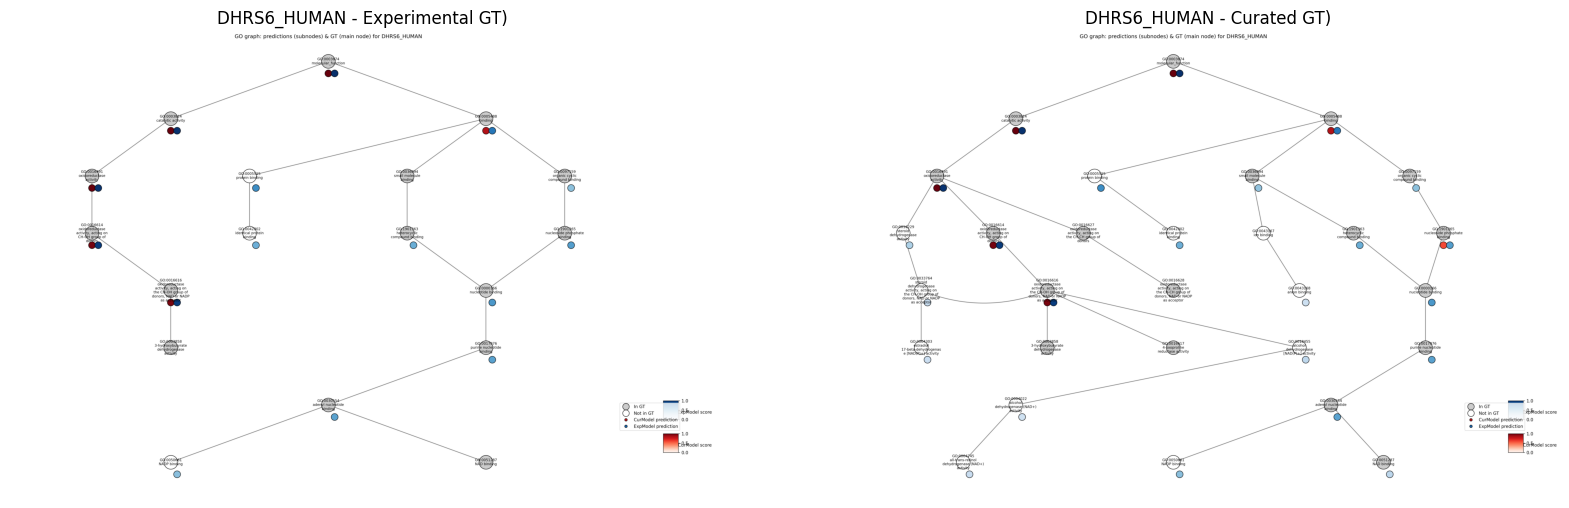

In [37]:
import matplotlib.image as mpimg
# Display the generated plots side-by-side
for _, row in bottom_10_df.iterrows():
    pid = row['protein_id']
    
    exp_img_path = f"pred_{pid}_exp.png"
    cur_img_path = f"pred_{pid}_cur.png"
    
    if os.path.exists(exp_img_path) and os.path.exists(cur_img_path):
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))
        
        img_exp = mpimg.imread(exp_img_path)
        axes[0].imshow(img_exp)
        axes[0].set_title(f"{pid} - Experimental GT)")
        axes[0].axis('off')
        
        img_cur = mpimg.imread(cur_img_path)
        axes[1].imshow(img_cur)
        axes[1].set_title(f"{pid} - Curated GT)")
        axes[1].axis('off')
    else:
        print(f"Missing images for {pid}")
    plt.show()
